<a href="https://colab.research.google.com/github/TeachFeastKunal/OIBSIP/blob/main/Unemployment_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install -q kaggle

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [37]:
import os
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sklearn.model_selection import train_test_split
from prophet import Prophet
from google.colab import userdata

In [5]:
os.environ['KAGGLE_USERNAME'] = userdata.get('KAGGLE_USERNAME')
os.environ['KAGGLE_KEY'] = userdata.get('KAGGLE_KEY')

In [6]:
file_path = kagglehub.dataset_download('gokulrajkmv/unemployment-in-india')
csv_path = os.listdir(file_path)[0]


100%|██████████| 16.0k/16.0k [00:00<00:00, 15.3MB/s]

Extracting files...


In [7]:
df = pd.read_csv(os.path.join(file_path , csv_path))
df.columns = df.columns.str.strip()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   Region                                   740 non-null    object 
 1   Date                                     740 non-null    object 
 2   Frequency                                740 non-null    object 
 3   Estimated Unemployment Rate (%)          740 non-null    float64
 4   Estimated Employed                       740 non-null    float64
 5   Estimated Labour Participation Rate (%)  740 non-null    float64
 6   Area                                     740 non-null    object 
dtypes: float64(3), object(4)
memory usage: 42.1+ KB


In [11]:
df['Date'] = pd.to_datetime(df['Date'] , dayfirst = True)
df.dropna(inplace = True)
df

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,2019-05-31,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,2019-06-30,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,2019-07-31,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,2019-08-31,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,2019-09-30,Monthly,5.17,12256762.0,44.68,Rural
...,...,...,...,...,...,...,...
749,West Bengal,2020-02-29,Monthly,7.55,10871168.0,44.09,Urban
750,West Bengal,2020-03-31,Monthly,6.67,10806105.0,43.34,Urban
751,West Bengal,2020-04-30,Monthly,15.63,9299466.0,41.20,Urban
752,West Bengal,2020-05-31,Monthly,15.22,9240903.0,40.67,Urban


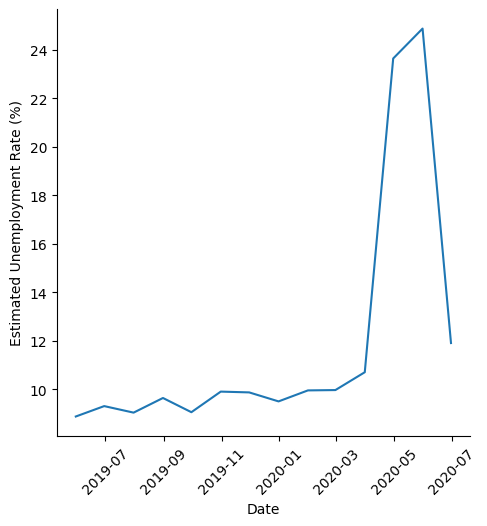

In [41]:
df_grouped = df.groupby('Date').agg({'Estimated Unemployment Rate (%)' : 'mean'}).reset_index()
line = sns.relplot(data= df_grouped , x = 'Date' , y = 'Estimated Unemployment Rate (%)' , kind = 'line')
line.tick_params(axis = 'x' , rotation = 45 )


In [10]:
state_bar = df.groupby('Region').agg({'Estimated Unemployment Rate (%)' : 'mean'}).sort_values(by = 'Estimated Unemployment Rate (%)' , ascending= False)
fig = px.bar(state_bar , x = state_bar.index , y = 'Estimated Unemployment Rate (%)' , color = state_bar.index )
fig.show()

In [40]:
# BOX PLOT for rate outliers
box = px.box(data_frame = df , x = 'Area' , y = 'Estimated Unemployment Rate (%)' , color = 'Area')
box.show()

# Time Series area comparison
df_area = df.groupby(['Date' , 'Area']).agg({'Estimated Unemployment Rate (%)' : 'mean'}).reset_index()
lineplot = px.line( data_frame = df_area , x = 'Date' , y = 'Estimated Unemployment Rate (%)' , color = 'Area' )
lineplot.show()


In [36]:
fig = px.sunburst(data_frame = df , path= ['Area' , 'Region'] , values = 'Estimated Unemployment Rate (%)' , color = 'Estimated Unemployment Rate (%)' , color_continuous_scale= 'RdYlGn_r')
fig.show()

In [42]:
df_grouped

,Date,Estimated Unemployment Rate (%)
0,2019-05-31,8.874259
1,2019-06-30,9.303333
2,2019-07-31,9.033889
3,2019-08-31,9.637925
4,2019-09-30,9.051731
5,2019-10-31,9.900909
6,2019-11-30,9.868364
7,2019-12-31,9.497358
8,2020-01-31,9.950755
9,2020-02-29,9.964717


### Modelling

INFO:prophet:n_changepoints greater than number of observations. Using 10.
/usr/local/lib/python3.12/dist-packages/prophet/forecaster.py:1875: FutureWarning:

'M' is deprecated and will be removed in a future version, please use 'ME' instead.



,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2019-05-31,4.288265,8.874260,8.874260,4.288265,4.288265,4.585995,4.585995,4.585995,4.585995,4.585995,4.585995,0.0,0.0,0.0,8.874260
1,2019-06-30,5.134688,9.303335,9.303335,5.134688,5.134688,4.168647,4.168647,4.168647,4.168647,4.168647,4.168647,0.0,0.0,0.0,9.303335
2,2019-07-31,6.009326,9.033888,9.033888,6.009326,6.009326,3.024562,3.024562,3.024562,3.024562,3.024562,3.024562,0.0,0.0,0.0,9.033888
3,2019-08-31,6.883965,9.637924,9.637924,6.883965,6.883965,2.753960,2.753960,2.753960,2.753960,2.753960,2.753960,0.0,0.0,0.0,9.637924
4,2019-09-30,7.730389,9.051730,9.051730,7.730389,7.730389,1.321341,1.321341,1.321341,1.321341,1.321341,1.321341,0.0,0.0,0.0,9.051730
5,2019-10-31,8.664689,9.900911,9.900911,8.664689,8.664689,1.236222,1.236222,1.236222,1.236222,1.236222,1.236222,0.0,0.0,0.0,9.900911
6,2019-11-30,9.568851,9.868363,9.868363,9.568851,9.568851,0.299512,0.299512,0.299512,0.299512,0.299512,0.299512,0.0,0.0,0.0,9.868363
7,2019-12-31,10.503151,9.497358,9.497358,10.503151,10.503151,-1.005793,-1.005793,-1.005793,-1.005793,-1.005793,-1.005793,0.0,0.0,0.0,9.497358
8,2020-01-31,11.437451,9.950755,9.950755,11.437451,11.437451,-1.486696,-1.486696,-1.486696,-1.486696,-1.486696,-1.486696,0.0,0.0,0.0,9.950755
9,2020-02-29,12.311474,9.964717,9.964717,12.311474,12.311474,-2.346757,-2.346757,-2.346757,-2.346757,-2.346757,-2.346757,0.0,0.0,0.0,9.964717


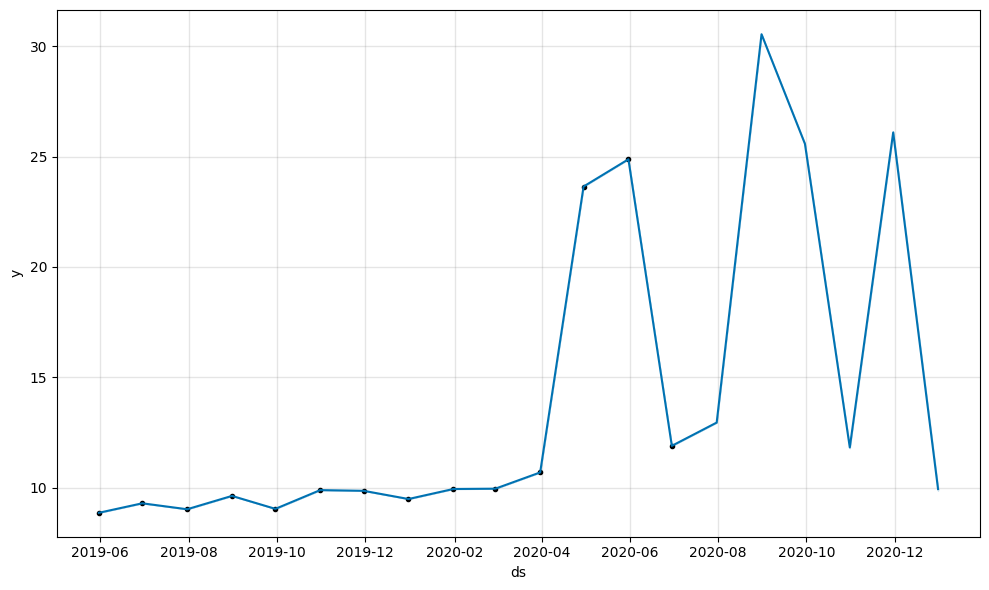

In [46]:
df_prophet = df_grouped.rename(columns = {'Date' : 'ds' , 'Estimated Unemployment Rate (%)' : 'y'})

model = Prophet(yearly_seasonality= True , weekly_seasonality = False , daily_seasonality= False )
model.fit(df_prophet)

prediction = model.make_future_dataframe(periods = 6 , freq = 'M')

forecast = model.predict(prediction)
fig = model.plot(forecast)
fig.show()
forecast